# AirPanel Question-Level Preference Models

This notebook tests whether per-question evaluation scores can reconstruct the final preference label.


## Setup

We use one row per respondent and one feature per question-dimension score difference.


In [1]:
from pathlib import Path
import json
import os
import re
import warnings

os.environ["MPLCONFIGDIR"] = str(Path("/private/tmp/matplotlib_airpanel_question_models"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, balanced_accuracy_score, brier_score_loss, f1_score, log_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    XGBClassifier = None
    HAS_XGBOOST = False

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.0)

SEED = 42
PROJECT_DIR = Path("/Users/martateodoratrales/Documents/New project")
QUESTION_SCORE_PATH = Path("/Users/martateodoratrales/Downloads/interviews_with_question_scores_mistral_7b_t4_full.csv")
RESPONDENT_METRICS_PATH = PROJECT_DIR / "airpanel_metric_outputs" / "respondent_construct_metrics.csv"
OUTPUT_DIR = PROJECT_DIR / "airpanel_question_model_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

print(QUESTION_SCORE_PATH)
print(RESPONDENT_METRICS_PATH)
print(OUTPUT_DIR)
print("xgboost_available:", HAS_XGBOOST)


/Users/martateodoratrales/Downloads/interviews_with_question_scores_mistral_7b_t4_full.csv
/Users/martateodoratrales/Documents/New project/airpanel_metric_outputs/respondent_construct_metrics.csv
/Users/martateodoratrales/Documents/New project/airpanel_question_model_outputs
xgboost_available: False


## Load Data

The target is the resolved preference: Bouygues versus Orange. Ties are excluded from supervised training.


In [2]:
wide = pd.read_csv(QUESTION_SCORE_PATH)
respondent = pd.read_csv(RESPONDENT_METRICS_PATH)

target_cols = [
    "panelist_id",
    "resolved_preference",
    "pref_bouygues_binary",
    "creativity_diff",
    "humour_diff",
    "originality_diff",
    "reliability_trust_diff",
    "intent_to_purchase_diff",
    "overall_diff",
]

target = respondent[[c for c in target_cols if c in respondent.columns]].copy()
df = wide.merge(target, on="panelist_id", how="inner")

counts = df["resolved_preference"].value_counts(dropna=False).rename_axis("resolved_preference").reset_index(name="n")
display(counts)
print("wide rows:", len(wide))
print("merged rows:", len(df))
print("unique panelists:", df["panelist_id"].nunique())


,resolved_preference,n
0,orange,594
1,bouygues,169
2,tie,37


wide rows: 800
merged rows: 800
unique panelists: 800


## Transposed Question-Dimension Table

Each feature is Bouygues score minus Orange score for one question and one dimension.


In [3]:
dimensions = ["creativity", "humour", "originality", "reliability_trust", "intent_to_purchase", "overall"]
base_dimensions = ["creativity", "humour", "originality", "reliability_trust", "intent_to_purchase"]
strict_dimensions = ["creativity", "humour", "originality", "reliability_trust"]
creative_dimensions = ["creativity", "humour", "originality"]
commercial_dimensions = ["reliability_trust", "intent_to_purchase"]

question_ids = sorted(
    {
        match.group(1)
        for col in df.columns
        for match in [re.match(r"creativity_(q\d+)_bouygues$", col)]
        if match
    },
    key=lambda x: int(x[1:])
)

def question_block(question_column):
    question_column = str(question_column)
    if question_column.startswith("Q_bouygues"):
        return "bouygues_specific"
    if question_column.startswith("Q_orange"):
        return "orange_specific"
    if question_column.startswith("Q_comparaison"):
        return "comparison"
    return "unknown"

def short_question_label(question_column):
    text = str(question_column)
    text = text.replace("Q_bouygues_", "B: ")
    text = text.replace("Q_orange_", "O: ")
    text = text.replace("Q_comparaison_", "C")
    text = text.replace("_1", "")
    text = text.replace("_2", " 2")
    text = text.replace("_", " ")
    return text

features = df[["panelist_id", "resolved_preference", "pref_bouygues_binary"]].copy()
metadata_rows = []

for qid in question_ids:
    q_col = f"question_column_{qid}"
    q_name = df[q_col].dropna().iloc[0] if q_col in df.columns and df[q_col].notna().any() else qid
    for dimension in dimensions:
        b_col = f"{dimension}_{qid}_bouygues"
        o_col = f"{dimension}_{qid}_orange"
        if b_col not in df.columns or o_col not in df.columns:
            continue
        feature = f"{dimension}_{qid}_diff"
        features[feature] = pd.to_numeric(df[b_col], errors="coerce") - pd.to_numeric(df[o_col], errors="coerce")
        metadata_rows.append(
            {
                "feature": feature,
                "source": "question",
                "question_id": qid,
                "question_number": int(qid[1:]),
                "question_column": q_name,
                "question_label": short_question_label(q_name),
                "question_block": question_block(q_name),
                "dimension": dimension,
            }
        )

for dimension in dimensions:
    col = f"{dimension}_diff"
    if col in df.columns:
        feature = f"aggregate_{dimension}_diff"
        features[feature] = pd.to_numeric(df[col], errors="coerce")
        metadata_rows.append(
            {
                "feature": feature,
                "source": "aggregate",
                "question_id": "aggregate",
                "question_number": 0,
                "question_column": "aggregate",
                "question_label": "Aggregate",
                "question_block": "aggregate",
                "dimension": dimension,
            }
        )

metadata = pd.DataFrame(metadata_rows)
model_df = features[features["pref_bouygues_binary"].isin([0, 1])].copy()
model_df["y"] = model_df["pref_bouygues_binary"].astype(int)

metadata.to_csv(TABLE_DIR / "question_model_feature_metadata.csv", index=False)
features.to_csv(TABLE_DIR / "question_model_feature_matrix_all_panelists.csv", index=False)
model_df.to_csv(TABLE_DIR / "question_model_training_matrix.csv", index=False)

display(metadata.head())
display(model_df["resolved_preference"].value_counts().rename_axis("class").reset_index(name="n"))
print("training rows:", len(model_df))
print("question features:", metadata.query("source == 'question'").shape[0])
print("aggregate features:", metadata.query("source == 'aggregate'").shape[0])


,feature,source,question_id,question_number,question_column,question_label,question_block,dimension
0,creativity_q1_diff,question,q1,1,Q_bouygues_reactions_spontanees_1,B: reactions spontanees,bouygues_specific,creativity
1,humour_q1_diff,question,q1,1,Q_bouygues_reactions_spontanees_1,B: reactions spontanees,bouygues_specific,humour
2,originality_q1_diff,question,q1,1,Q_bouygues_reactions_spontanees_1,B: reactions spontanees,bouygues_specific,originality
3,reliability_trust_q1_diff,question,q1,1,Q_bouygues_reactions_spontanees_1,B: reactions spontanees,bouygues_specific,reliability_trust
4,intent_to_purchase_q1_diff,question,q1,1,Q_bouygues_reactions_spontanees_1,B: reactions spontanees,bouygues_specific,intent_to_purchase


,class,n
0,orange,594
1,bouygues,169


training rows: 763
question features: 132
aggregate features: 6


## Feature Sets

The strict sets are the most important ones because they remove preference-adjacent signals.


In [4]:
def feature_names(source=None, dimensions_keep=None, blocks_keep=None, blocks_drop=None, questions_drop=None, include_overall=True):
    m = metadata.copy()
    if source is not None:
        m = m[m["source"].isin(source if isinstance(source, list) else [source])]
    if dimensions_keep is not None:
        m = m[m["dimension"].isin(dimensions_keep)]
    if not include_overall:
        m = m[m["dimension"].ne("overall")]
    if blocks_keep is not None:
        m = m[m["question_block"].isin(blocks_keep)]
    if blocks_drop is not None:
        m = m[~m["question_block"].isin(blocks_drop)]
    if questions_drop is not None:
        m = m[~m["question_id"].isin(questions_drop)]
    return m["feature"].tolist()

feature_sets = {
    "aggregate_non_overall": feature_names(source="aggregate", dimensions_keep=base_dimensions),
    "all_non_overall": feature_names(source="question", dimensions_keep=base_dimensions),
    "strict_no_overall_no_intent": feature_names(source="question", dimensions_keep=strict_dimensions),
    "creative_only": feature_names(source="question", dimensions_keep=creative_dimensions),
    "commercial_only": feature_names(source="question", dimensions_keep=commercial_dimensions),
    "comparison_only_non_overall": feature_names(source="question", dimensions_keep=base_dimensions, blocks_keep=["comparison"]),
    "no_comparison_non_overall": feature_names(source="question", dimensions_keep=base_dimensions, blocks_drop=["comparison"]),
    "q2_removed_non_overall": feature_names(source="question", dimensions_keep=base_dimensions, questions_drop=["q2"]),
    "overall_only_diagnostic": feature_names(source="question", dimensions_keep=["overall"]),
    "all_dimensions_diagnostic": feature_names(source="question", dimensions_keep=dimensions),
}

feature_set_table = pd.DataFrame(
    [{"feature_set": name, "n_features": len(cols)} for name, cols in feature_sets.items()]
).sort_values("feature_set")

feature_set_table.to_csv(TABLE_DIR / "question_model_feature_sets.csv", index=False)
display(feature_set_table)


,feature_set,n_features
0,aggregate_non_overall,5
9,all_dimensions_diagnostic,132
1,all_non_overall,110
4,commercial_only,44
5,comparison_only_non_overall,30
3,creative_only,66
6,no_comparison_non_overall,80
8,overall_only_diagnostic,22
7,q2_removed_non_overall,105
2,strict_no_overall_no_intent,88


## Models

Elastic-net logistic regression is the main interpretable model. XGBoost is the ambitious nonlinear model.


In [5]:
def make_majority(y_train):
    return DummyClassifier(strategy="most_frequent")

def make_l2_logistic(y_train):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(penalty="l2", C=1.0, class_weight="balanced", max_iter=5000, random_state=SEED)),
        ]
    )

def make_elastic_net(y_train):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(penalty="elasticnet", solver="saga", l1_ratio=0.6, C=0.3, class_weight="balanced", max_iter=5000, random_state=SEED)),
        ]
    )

def make_random_forest(y_train):
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=8, class_weight="balanced", random_state=SEED, n_jobs=-1)),
        ]
    )

def make_ambitious_model(y_train):
    n_pos = int(np.sum(np.asarray(y_train) == 1))
    n_neg = int(np.sum(np.asarray(y_train) == 0))
    weight = n_neg / max(n_pos, 1)
    if HAS_XGBOOST:
        return Pipeline(
            [
                ("imputer", SimpleImputer(strategy="median")),
                ("model", XGBClassifier(n_estimators=350, max_depth=2, learning_rate=0.035, subsample=0.9, colsample_bytree=0.9, reg_lambda=2.0, reg_alpha=0.15, objective="binary:logistic", eval_metric="logloss", scale_pos_weight=weight, random_state=SEED, n_jobs=2, verbosity=0)),
            ]
        )
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(loss="log_loss", learning_rate=0.04, max_iter=250, max_leaf_nodes=15, l2_regularization=0.05, class_weight="balanced", random_state=SEED)),
        ]
    )

model_factories = {
    "majority_baseline": make_majority,
    "l2_logistic": make_l2_logistic,
    "elastic_net_logistic": make_elastic_net,
    "random_forest": make_random_forest,
    "ambitious_xgboost" if HAS_XGBOOST else "ambitious_hist_gradient_boosting": make_ambitious_model,
}

print(list(model_factories.keys()))


['majority_baseline', 'l2_logistic', 'elastic_net_logistic', 'random_forest', 'ambitious_hist_gradient_boosting']


## Cross-Validated Evaluation

We report performance under the same stratified folds for every model and feature set.


In [6]:
def positive_probability(model, x):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(x)
        classes = list(model.classes_)
        if 1 in classes:
            return proba[:, classes.index(1)]
        return np.zeros(x.shape[0])
    scores = model.decision_function(x)
    return 1 / (1 + np.exp(-scores))

def clipped(proba):
    return np.clip(np.asarray(proba, dtype=float), 1e-6, 1 - 1e-6)

def compute_metrics(y_true, proba, pred):
    proba = clipped(proba)
    return {
        "roc_auc": roc_auc_score(y_true, proba),
        "average_precision": average_precision_score(y_true, proba),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1_bouygues": f1_score(y_true, pred, zero_division=0),
        "brier": brier_score_loss(y_true, proba),
        "log_loss": log_loss(y_true, proba, labels=[0, 1]),
    }

def evaluate_model(model_name, model_factory, feature_set, columns, y_override=None):
    data = model_df.reset_index(drop=True).copy()
    x = data[columns].astype(float)
    y = data["y"].to_numpy() if y_override is None else np.asarray(y_override, dtype=int)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_proba = np.full(len(y), np.nan)
    oof_pred = np.full(len(y), np.nan)
    fold_rows = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(x, y), start=1):
        x_train = x.iloc[train_idx]
        x_test = x.iloc[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        model = model_factory(y_train)
        model.fit(x_train, y_train)
        proba = positive_probability(model, x_test)
        pred = (proba >= 0.5).astype(int)
        oof_proba[test_idx] = proba
        oof_pred[test_idx] = pred
        fold_metric = compute_metrics(y_test, proba, pred)
        fold_metric.update({"model": model_name, "feature_set": feature_set, "fold": fold, "n_train": len(train_idx), "n_test": len(test_idx)})
        fold_rows.append(fold_metric)
    aggregate = compute_metrics(y, oof_proba, oof_pred.astype(int))
    aggregate.update(
        {
            "model": model_name,
            "feature_set": feature_set,
            "n": len(y),
            "n_features": len(columns),
            "positive_rate": float(np.mean(y)),
            "fold_roc_auc_sd": float(pd.DataFrame(fold_rows)["roc_auc"].std(ddof=1)),
            "fold_balanced_accuracy_sd": float(pd.DataFrame(fold_rows)["balanced_accuracy"].std(ddof=1)),
            "fold_average_precision_sd": float(pd.DataFrame(fold_rows)["average_precision"].std(ddof=1)),
        }
    )
    predictions = data[["panelist_id", "resolved_preference"]].copy()
    predictions["model"] = model_name
    predictions["feature_set"] = feature_set
    predictions["y_true"] = y
    predictions["predicted_bouygues_probability"] = oof_proba
    predictions["y_pred"] = oof_pred.astype(int)
    return aggregate, pd.DataFrame(fold_rows), predictions

all_results = []
all_folds = []
all_predictions = []

for feature_set, columns in feature_sets.items():
    for model_name, factory in model_factories.items():
        result, folds, predictions = evaluate_model(model_name, factory, feature_set, columns)
        all_results.append(result)
        all_folds.append(folds)
        all_predictions.append(predictions)

results = pd.DataFrame(all_results).sort_values(["roc_auc", "balanced_accuracy"], ascending=False)
fold_results = pd.concat(all_folds, ignore_index=True)
predictions = pd.concat(all_predictions, ignore_index=True)

results.to_csv(TABLE_DIR / "question_model_comparison_results.csv", index=False)
fold_results.to_csv(TABLE_DIR / "question_model_fold_results.csv", index=False)
predictions.to_csv(TABLE_DIR / "question_model_oof_predictions.csv", index=False)

display(results.head(15).round(3))


,roc_auc,average_precision,balanced_accuracy,f1_bouygues,brier,log_loss,model,feature_set,n,n_features,positive_rate,fold_roc_auc_sd,fold_balanced_accuracy_sd,fold_average_precision_sd
1,0.998,0.994,0.968,0.906,0.021,0.067,l2_logistic,aggregate_non_overall,763,5,0.221,0.001,0.011,0.004
2,0.998,0.994,0.968,0.906,0.023,0.077,elastic_net_logistic,aggregate_non_overall,763,5,0.221,0.001,0.011,0.004
3,0.997,0.991,0.970,0.942,0.023,0.082,random_forest,aggregate_non_overall,763,5,0.221,0.002,0.013,0.007
4,0.997,0.991,0.969,0.937,0.021,0.064,ambitious_hist_gradient_boosting,aggregate_non_overall,763,5,0.221,0.001,0.005,0.003
17,0.935,0.861,0.872,0.798,0.075,0.293,elastic_net_logistic,creative_only,763,66,0.221,0.035,0.030,0.055
7,0.933,0.869,0.863,0.796,0.073,0.280,elastic_net_logistic,all_non_overall,763,110,0.221,0.032,0.053,0.053
47,0.929,0.869,0.869,0.804,0.072,0.276,elastic_net_logistic,all_dimensions_diagnostic,763,132,0.221,0.031,0.046,0.052
12,0.923,0.851,0.858,0.776,0.077,0.295,elastic_net_logistic,strict_no_overall_no_intent,763,88,0.221,0.036,0.043,0.055
13,0.919,0.859,0.878,0.778,0.100,0.359,random_forest,strict_no_overall_no_intent,763,88,0.221,0.038,0.039,0.065
18,0.919,0.849,0.882,0.784,0.101,0.359,random_forest,creative_only,763,66,0.221,0.040,0.042,0.071


## Negative Control

The strict representation should fail when the preference labels are shuffled.


In [7]:
rng = np.random.default_rng(SEED)
y_shuffled = rng.permutation(model_df["y"].to_numpy())
negative_rows = []
negative_folds = []

for model_name in ["elastic_net_logistic", "ambitious_xgboost" if HAS_XGBOOST else "ambitious_hist_gradient_boosting"]:
    result, folds, _ = evaluate_model(model_name, model_factories[model_name], "strict_no_overall_no_intent_shuffled_labels", feature_sets["strict_no_overall_no_intent"], y_override=y_shuffled)
    negative_rows.append(result)
    negative_folds.append(folds)

negative_control = pd.DataFrame(negative_rows)
negative_fold_results = pd.concat(negative_folds, ignore_index=True)
negative_control.to_csv(TABLE_DIR / "question_model_negative_control.csv", index=False)
negative_fold_results.to_csv(TABLE_DIR / "question_model_negative_control_folds.csv", index=False)
display(negative_control.round(3))


,roc_auc,average_precision,balanced_accuracy,f1_bouygues,brier,log_loss,model,feature_set,n,n_features,positive_rate,fold_roc_auc_sd,fold_balanced_accuracy_sd,fold_average_precision_sd
0,0.467,0.215,0.466,0.271,0.262,0.741,elastic_net_logistic,strict_no_overall_no_intent_shuffled_labels,763,88,0.221,0.018,0.021,0.024
1,0.446,0.200,0.464,0.189,0.255,0.731,ambitious_hist_gradient_boosting,strict_no_overall_no_intent_shuffled_labels,763,88,0.221,0.030,0.035,0.021


## Performance Figures

These figures compare models across feature sets.


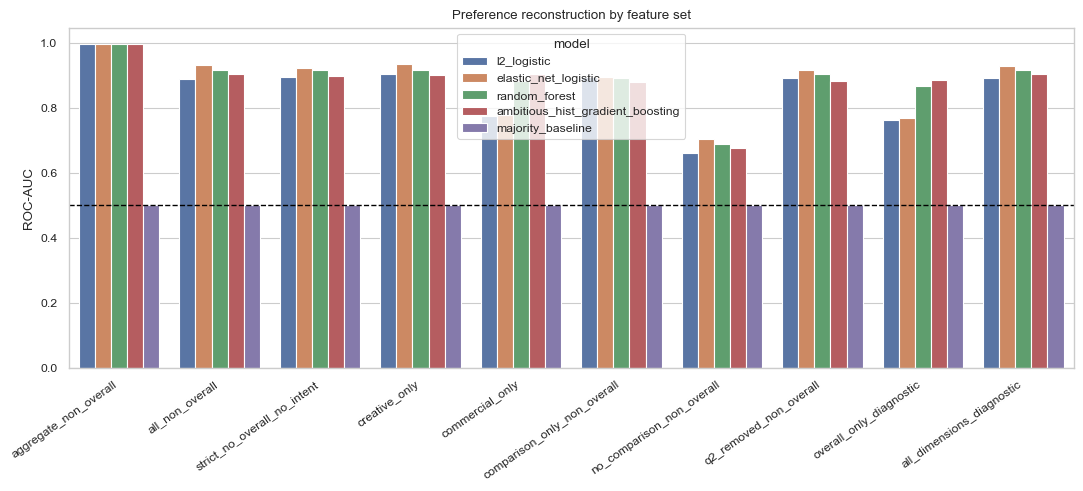

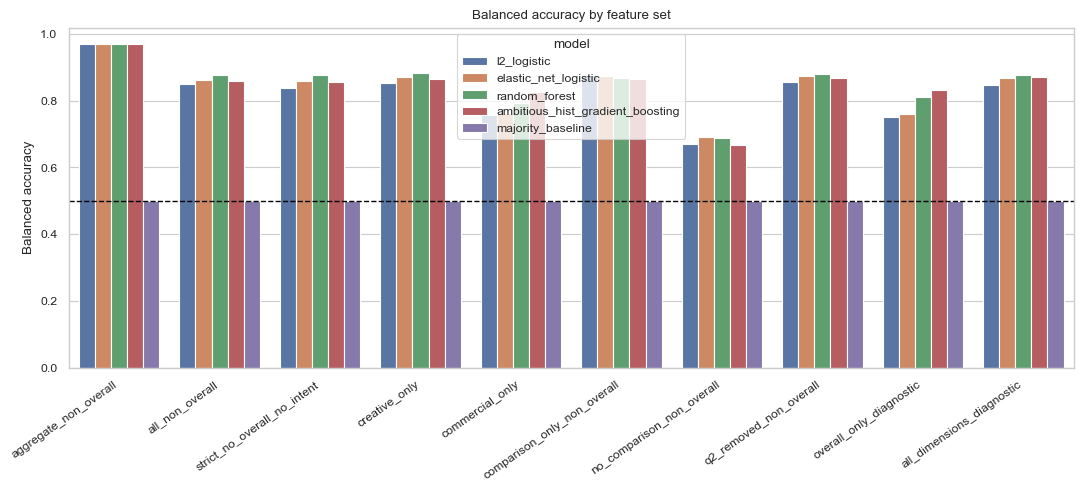

In [8]:
plot_results = results.copy()
plot_results["feature_set"] = pd.Categorical(plot_results["feature_set"], categories=list(feature_sets.keys()), ordered=True)
plot_results = plot_results.sort_values("feature_set")

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_results, x="feature_set", y="roc_auc", hue="model")
plt.axhline(0.5, color="black", linewidth=1, linestyle="--")
plt.xticks(rotation=35, ha="right")
plt.xlabel("")
plt.ylabel("ROC-AUC")
plt.title("Preference reconstruction by feature set")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_auc_by_feature_set.png", dpi=220)
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_results, x="feature_set", y="balanced_accuracy", hue="model")
plt.axhline(0.5, color="black", linewidth=1, linestyle="--")
plt.xticks(rotation=35, ha="right")
plt.xlabel("")
plt.ylabel("Balanced accuracy")
plt.title("Balanced accuracy by feature set")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_balanced_accuracy_by_feature_set.png", dpi=220)
plt.show()


## Main Sparse Model

We inspect elastic-net coefficients on the strict non-leaky representation.


In [9]:
MAIN_FEATURE_SET = "strict_no_overall_no_intent"
main_columns = feature_sets[MAIN_FEATURE_SET]
x_main = model_df[main_columns].astype(float)
y_main = model_df["y"].to_numpy()

elastic_model = make_elastic_net(y_main)
elastic_model.fit(x_main, y_main)

coef = elastic_model.named_steps["model"].coef_[0]
coef_table = pd.DataFrame({"feature": main_columns, "coefficient": coef})
coef_table["abs_coefficient"] = coef_table["coefficient"].abs()
coef_table = coef_table.merge(metadata, on="feature", how="left")
coef_table["direction"] = np.where(coef_table["coefficient"] > 0, "toward_bouygues", np.where(coef_table["coefficient"] < 0, "toward_orange", "zero"))
coef_table = coef_table.sort_values("abs_coefficient", ascending=False)
coef_table.to_csv(TABLE_DIR / "elastic_net_selected_features_strict.csv", index=False)

selected = coef_table[coef_table["abs_coefficient"].gt(1e-8)].copy()
selected.to_csv(TABLE_DIR / "elastic_net_nonzero_features_strict.csv", index=False)

display(selected.head(20)[["feature", "question_label", "dimension", "question_block", "coefficient", "direction"]].round(3))
print("nonzero coefficients:", len(selected))


,feature,question_label,dimension,question_block,coefficient,direction
86,originality_q22_diff,C6,originality,comparison,1.735,toward_bouygues
84,creativity_q22_diff,C6,creativity,comparison,0.725,toward_bouygues
82,originality_q21_diff,C5,originality,comparison,0.611,toward_bouygues
5,humour_q2_diff,B: memorisation,humour,bouygues_specific,0.421,toward_bouygues
67,reliability_trust_q17_diff,C1,reliability_trust,comparison,0.381,toward_bouygues
63,reliability_trust_q16_diff,O: intention achat,reliability_trust,orange_specific,0.372,toward_bouygues
42,originality_q11_diff,O: caractere distinctif,originality,orange_specific,0.325,toward_bouygues
44,creativity_q12_diff,O: attractivite,creativity,orange_specific,-0.319,toward_orange
80,creativity_q21_diff,C5,creativity,comparison,0.296,toward_bouygues
29,humour_q8_diff,B: intention achat,humour,bouygues_specific,-0.290,toward_orange


nonzero coefficients: 49


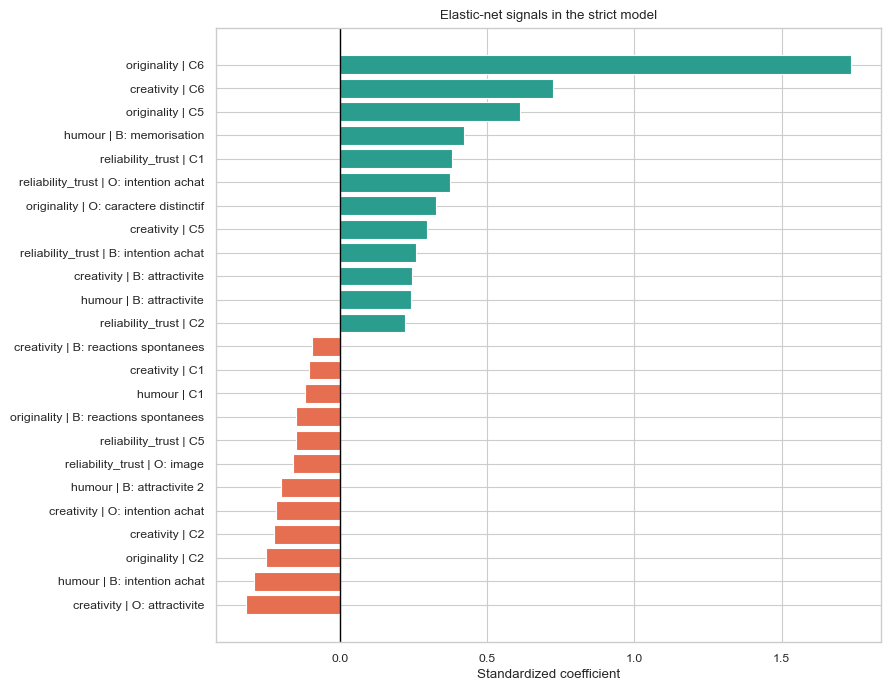

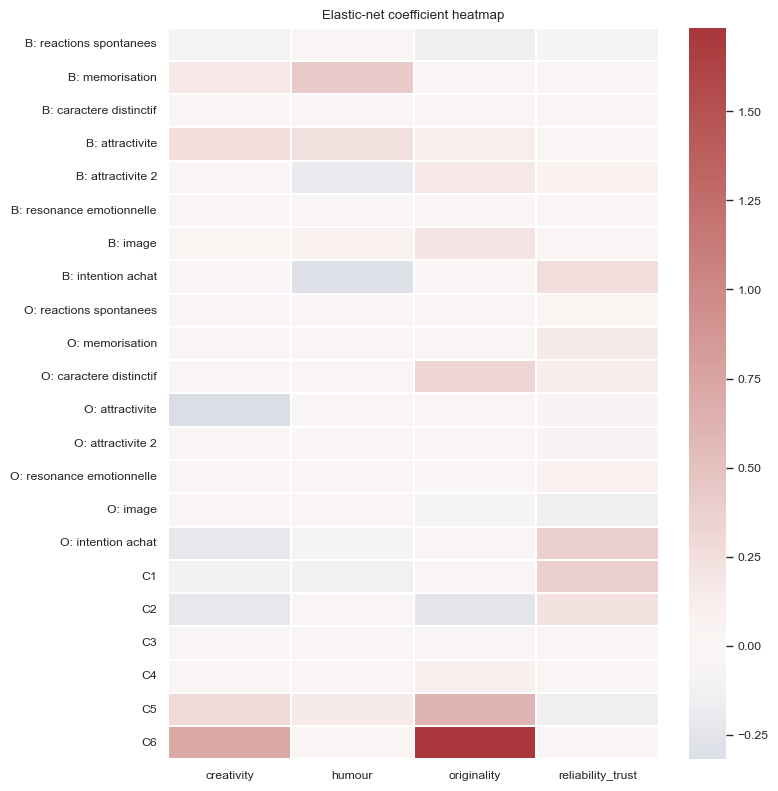

In [10]:
top_pos = coef_table.sort_values("coefficient", ascending=False).head(12)
top_neg = coef_table.sort_values("coefficient", ascending=True).head(12)
top_coef = pd.concat([top_neg, top_pos], ignore_index=True)
top_coef["label"] = top_coef["dimension"] + " | " + top_coef["question_label"]
top_coef = top_coef.sort_values("coefficient")

plt.figure(figsize=(9, 7))
colors = np.where(top_coef["coefficient"] >= 0, "#2A9D8F", "#E76F51")
plt.barh(top_coef["label"], top_coef["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Standardized coefficient")
plt.ylabel("")
plt.title("Elastic-net signals in the strict model")
plt.tight_layout()
plt.savefig(FIG_DIR / "elastic_net_top_features_strict.png", dpi=220)
plt.show()

heat = coef_table.pivot_table(index="question_label", columns="dimension", values="coefficient", aggfunc="mean").fillna(0)
order = metadata.query("source == 'question'").drop_duplicates("question_label").sort_values("question_number")["question_label"].tolist()
heat = heat.reindex([x for x in order if x in heat.index])

plt.figure(figsize=(8, 8))
sns.heatmap(heat, center=0, cmap="vlag", linewidths=0.3, linecolor="white")
plt.xlabel("")
plt.ylabel("")
plt.title("Elastic-net coefficient heatmap")
plt.tight_layout()
plt.savefig(FIG_DIR / "elastic_net_coefficient_heatmap_strict.png", dpi=220)
plt.show()


## Ambitious Model Interpretation

We inspect the nonlinear model on the same strict representation.


In [11]:
ambitious_name = "ambitious_xgboost" if HAS_XGBOOST else "ambitious_hist_gradient_boosting"
ambitious_model = make_ambitious_model(y_main)
ambitious_model.fit(x_main, y_main)

importance_model = ambitious_model.named_steps["model"] if hasattr(ambitious_model, "named_steps") else ambitious_model

if hasattr(importance_model, "feature_importances_"):
    importances = importance_model.feature_importances_
    importance_kind = "native"
else:
    perm = permutation_importance(ambitious_model, x_main, y_main, n_repeats=8, random_state=SEED, scoring="roc_auc", n_jobs=-1)
    importances = perm.importances_mean
    importance_kind = "permutation"

importance = pd.DataFrame({"feature": main_columns, "importance": importances})
importance = importance.merge(metadata, on="feature", how="left").sort_values("importance", ascending=False)
importance["importance_kind"] = importance_kind
importance.to_csv(TABLE_DIR / "ambitious_model_feature_importance_strict.csv", index=False)

display(importance.head(20)[["feature", "question_label", "dimension", "question_block", "importance"]].round(4))
print("ambitious model:", ambitious_name)
print("importance kind:", importance_kind)


,feature,question_label,dimension,question_block,importance
86,originality_q22_diff,C6,originality,comparison,0.1111
12,creativity_q4_diff,B: attractivite,creativity,bouygues_specific,0.0128
82,originality_q21_diff,C5,originality,comparison,0.0127
5,humour_q2_diff,B: memorisation,humour,bouygues_specific,0.0078
84,creativity_q22_diff,C6,creativity,comparison,0.0075
39,reliability_trust_q10_diff,O: memorisation,reliability_trust,orange_specific,0.0045
87,reliability_trust_q22_diff,C6,reliability_trust,comparison,0.0031
68,creativity_q18_diff,C2,creativity,comparison,0.0027
17,humour_q5_diff,B: attractivite 2,humour,bouygues_specific,0.0018
63,reliability_trust_q16_diff,O: intention achat,reliability_trust,orange_specific,0.0017


ambitious model: ambitious_hist_gradient_boosting
importance kind: permutation


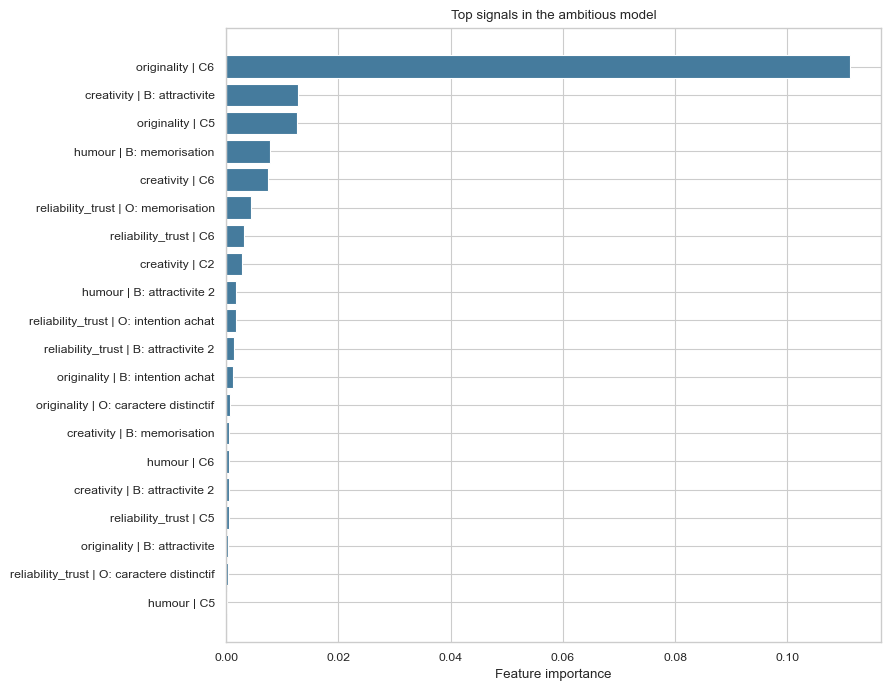

In [12]:
top_importance = importance.head(20).copy()
top_importance["label"] = top_importance["dimension"] + " | " + top_importance["question_label"]
top_importance = top_importance.sort_values("importance")

plt.figure(figsize=(9, 7))
plt.barh(top_importance["label"], top_importance["importance"], color="#457B9D")
plt.xlabel("Feature importance")
plt.ylabel("")
plt.title("Top signals in the ambitious model")
plt.tight_layout()
plt.savefig(FIG_DIR / "ambitious_model_top_features_strict.png", dpi=220)
plt.show()


## Calibration

This checks whether predicted probabilities behave sensibly, not only whether rankings are good.


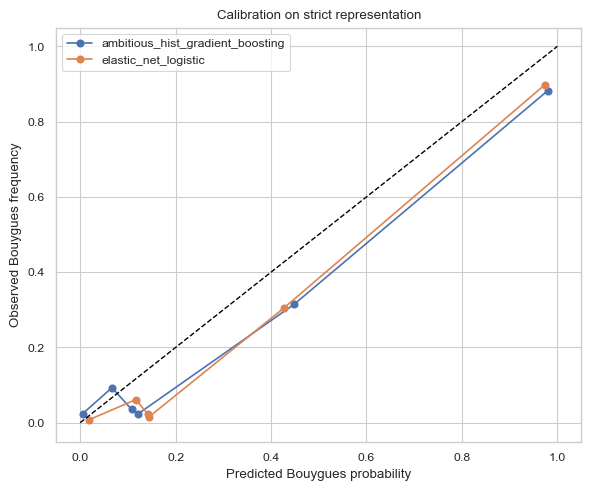

In [13]:
main_predictions = predictions[
    predictions["feature_set"].eq(MAIN_FEATURE_SET)
    & predictions["model"].isin(["elastic_net_logistic", ambitious_name])
].copy()

plt.figure(figsize=(6, 5))
for model_name, group in main_predictions.groupby("model"):
    prob_true, prob_pred = calibration_curve(group["y_true"], group["predicted_bouygues_probability"], n_bins=6, strategy="quantile")
    plt.plot(prob_pred, prob_true, marker="o", label=model_name)
plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
plt.xlabel("Predicted Bouygues probability")
plt.ylabel("Observed Bouygues frequency")
plt.title("Calibration on strict representation")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "calibration_strict_models.png", dpi=220)
plt.show()


## Compact Paper Tables

These tables are ready to move into a draft.


In [14]:
main_table = results[
    results["feature_set"].isin(["aggregate_non_overall", "all_non_overall", "strict_no_overall_no_intent", "no_comparison_non_overall", "comparison_only_non_overall", "overall_only_diagnostic"])
].copy()

main_table = main_table[
    [
        "model",
        "feature_set",
        "n_features",
        "roc_auc",
        "average_precision",
        "balanced_accuracy",
        "f1_bouygues",
        "brier",
        "log_loss",
        "fold_roc_auc_sd",
        "fold_balanced_accuracy_sd",
    ]
].sort_values(["feature_set", "roc_auc"], ascending=[True, False])

best_by_feature_set = results.sort_values(["feature_set", "roc_auc"], ascending=[True, False]).groupby("feature_set", as_index=False).head(1)
best_by_feature_set = best_by_feature_set[["feature_set", "model", "n_features", "roc_auc", "average_precision", "balanced_accuracy", "f1_bouygues", "brier", "log_loss"]]

main_table.to_csv(TABLE_DIR / "paper_table_question_model_comparison.csv", index=False)
best_by_feature_set.to_csv(TABLE_DIR / "paper_table_best_by_feature_set.csv", index=False)

with open(TABLE_DIR / "paper_table_question_model_comparison.tex", "w") as f:
    f.write(main_table.round(3).to_latex(index=False))

with open(TABLE_DIR / "paper_table_best_by_feature_set.tex", "w") as f:
    f.write(best_by_feature_set.round(3).to_latex(index=False))

display(main_table.round(3).head(20))
display(best_by_feature_set.round(3))


,model,feature_set,n_features,roc_auc,average_precision,balanced_accuracy,f1_bouygues,brier,log_loss,fold_roc_auc_sd,fold_balanced_accuracy_sd
1,l2_logistic,aggregate_non_overall,5,0.998,0.994,0.968,0.906,0.021,0.067,0.001,0.011
2,elastic_net_logistic,aggregate_non_overall,5,0.998,0.994,0.968,0.906,0.023,0.077,0.001,0.011
3,random_forest,aggregate_non_overall,5,0.997,0.991,0.970,0.942,0.023,0.082,0.002,0.013
4,ambitious_hist_gradient_boosting,aggregate_non_overall,5,0.997,0.991,0.969,0.937,0.021,0.064,0.001,0.005
0,majority_baseline,aggregate_non_overall,5,0.500,0.221,0.500,0.000,0.221,3.060,0.000,0.000
7,elastic_net_logistic,all_non_overall,110,0.933,0.869,0.863,0.796,0.073,0.280,0.032,0.053
8,random_forest,all_non_overall,110,0.917,0.859,0.876,0.777,0.101,0.360,0.040,0.043
9,ambitious_hist_gradient_boosting,all_non_overall,110,0.905,0.849,0.859,0.781,0.077,0.292,0.052,0.041
6,l2_logistic,all_non_overall,110,0.890,0.829,0.848,0.769,0.084,0.350,0.046,0.043
5,majority_baseline,all_non_overall,110,0.500,0.221,0.500,0.000,0.221,3.060,0.000,0.000


,feature_set,model,n_features,roc_auc,average_precision,balanced_accuracy,f1_bouygues,brier,log_loss
1,aggregate_non_overall,l2_logistic,5,0.998,0.994,0.968,0.906,0.021,0.067
47,all_dimensions_diagnostic,elastic_net_logistic,132,0.929,0.869,0.869,0.804,0.072,0.276
7,all_non_overall,elastic_net_logistic,110,0.933,0.869,0.863,0.796,0.073,0.280
24,commercial_only,ambitious_hist_gradient_boosting,44,0.904,0.835,0.824,0.718,0.090,0.311
27,comparison_only_non_overall,elastic_net_logistic,30,0.897,0.842,0.873,0.816,0.078,0.304
17,creative_only,elastic_net_logistic,66,0.935,0.861,0.872,0.798,0.075,0.293
32,no_comparison_non_overall,elastic_net_logistic,80,0.704,0.477,0.691,0.519,0.191,0.593
44,overall_only_diagnostic,ambitious_hist_gradient_boosting,22,0.885,0.800,0.831,0.710,0.103,0.353
37,q2_removed_non_overall,elastic_net_logistic,105,0.918,0.859,0.874,0.812,0.074,0.286
12,strict_no_overall_no_intent,elastic_net_logistic,88,0.923,0.851,0.858,0.776,0.077,0.295


## Run Summary

The key comparison is strict real labels versus shuffled labels.


In [15]:
strict_results = results[results["feature_set"].eq(MAIN_FEATURE_SET)].sort_values("roc_auc", ascending=False)
best_strict = strict_results.iloc[0].to_dict()
elastic_strict = results[(results["feature_set"].eq(MAIN_FEATURE_SET)) & (results["model"].eq("elastic_net_logistic"))].iloc[0].to_dict()
ambitious_strict = results[(results["feature_set"].eq(MAIN_FEATURE_SET)) & (results["model"].eq(ambitious_name))].iloc[0].to_dict()

summary = {
    "n_training_panelists": int(len(model_df)),
    "positive_class": "Bouygues",
    "class_counts": model_df["resolved_preference"].value_counts().to_dict(),
    "main_feature_set": MAIN_FEATURE_SET,
    "ambitious_model": ambitious_name,
    "best_strict_model": best_strict["model"],
    "best_strict_roc_auc": float(best_strict["roc_auc"]),
    "elastic_strict_roc_auc": float(elastic_strict["roc_auc"]),
    "elastic_strict_balanced_accuracy": float(elastic_strict["balanced_accuracy"]),
    "ambitious_strict_roc_auc": float(ambitious_strict["roc_auc"]),
    "ambitious_strict_balanced_accuracy": float(ambitious_strict["balanced_accuracy"]),
    "negative_control": negative_control[["model", "roc_auc", "balanced_accuracy", "average_precision"]].to_dict(orient="records"),
    "outputs": {
        "tables": str(TABLE_DIR),
        "figures": str(FIG_DIR),
    },
}

with open(OUTPUT_DIR / "question_model_run_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))


{
  "n_training_panelists": 763,
  "positive_class": "Bouygues",
  "class_counts": {
    "orange": 594,
    "bouygues": 169
  },
  "main_feature_set": "strict_no_overall_no_intent",
  "ambitious_model": "ambitious_hist_gradient_boosting",
  "best_strict_model": "elastic_net_logistic",
  "best_strict_roc_auc": 0.9225688841073456,
  "elastic_strict_roc_auc": 0.9225688841073456,
  "elastic_strict_balanced_accuracy": 0.8577042615504153,
  "ambitious_strict_roc_auc": 0.897092224015301,
  "ambitious_strict_balanced_accuracy": 0.8543372581834121,
  "negative_control": [
    {
      "model": "elastic_net_logistic",
      "roc_auc": 0.4666885820731974,
      "balanced_accuracy": 0.46597633136094674,
      "average_precision": 0.21462917947681318
    },
    {
      "model": "ambitious_hist_gradient_boosting",
      "roc_auc": 0.4464417349032733,
      "balanced_accuracy": 0.46381965612734843,
      "average_precision": 0.1997033737324847
    }
  ],
  "outputs": {
    "tables": "/Users/martateodo